# Multi-Factor Portfolio Research Framework — Indian Equities
## Notebook 03: Portfolio Construction

Consumes NB02's factor panel (composite score, monthly grid) and constructs the actual portfolio
holdings: Top-20 stock selection, two weighting schemes (Equal Weight and True Equal Risk
Contribution), across three rebalancing frequencies (Monthly / Quarterly / Semi-Annual).

**Scope boundary (confirmed):** this notebook produces *weights only* — no returns are compounded,
no performance metrics are computed, and no transaction costs are applied here. That is Notebook 04
(Walk-Forward Backtest) and Notebook 05 (Portfolio Analytics)'s job. Per the standing project rule,
no starting capital or "portfolio value" language appears anywhere below.

**Locked decisions carried into this notebook (confirmed with the user before building):**
- **Liquidity filter:** no additional liquidity/traded-value filter beyond the history requirement
  already implicit in the factor panel (a stock needs all four factor z-scores present, which itself
  requires ~756 trading days of history for Max Drawdown/Beta). This was an explicit choice — the
  point-in-time coverage question flagged in NB01/NB02 is resolved as "history requirement alone is
  enough," not silently assumed.
- **ERC covariance lookback:** 756 trading days, matching the Max Drawdown/Beta window elsewhere in
  the project, for consistency.
- **Under-sized eligible universe (< 20 stocks) at a rebalance date:** construct the portfolio from
  all eligible stocks available that date (portfolio temporarily < 20), log the event explicitly, and
  do not modify any filtering rule to compensate.


### Cell 1 — Install Packages

In [1]:
!pip install pandas numpy matplotlib scipy yfinance --quiet


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: C:\Users\vidya\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip


### Cell 2 — Configuration & Dark Theme

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import warnings
import os
import json

warnings.filterwarnings('ignore')

BASE_DIR   = '.'
DATA_DIR   = os.path.join(BASE_DIR, 'data')
OUTPUT_DIR = os.path.join(BASE_DIR, 'output')
os.makedirs(DATA_DIR,   exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ══════════════════════════════════════════════════════════════════════════════
#  ▶▶  PORTFOLIO CONSTRUCTION PARAMETERS (locked)  ◀◀
# ══════════════════════════════════════════════════════════════════════════════
TARGET_PORTFOLIO_SIZE = 20   # Top-20 by composite score

# Rebalance frequencies -- all subset from NB02's monthly grid (every Nth month-end)
REBAL_FREQ_STEP = {
    'Monthly':     1,
    'Quarterly':   3,
    'SemiAnnual':  6,
}

WEIGHTING_SCHEMES = ['EqualWeight', 'ERC']

# True ERC optimizer settings
ERC_COV_LOOKBACK_DAYS = 756   # matches Max Drawdown / Beta window, for consistency (locked)
ERC_MIN_OBS           = 100   # minimum daily-return observations required to attempt ERC at all;
                               # below this, covariance estimates are too noisy to trust -- falls
                               # back to Equal Weight for that (date, frequency) combination, logged
ERC_MAX_ITER          = 500
ERC_COND_NUMBER_FLAG  = 1e6   # covariance matrices with condition number above this are flagged as
                               # near-singular/degenerate in diagnostics and shrunk toward their
                               # diagonal before optimization (see Cell 8)
ERC_SHRINKAGE_ALPHA   = 0.10  # shrinkage intensity applied ONLY to flagged near-singular matrices
                               # (blend toward a diagonal target of the same average variance) --
                               # a light regularisation, not a general-purpose shrinkage estimator

ANN_FACTOR       = 252
RISK_FREE_RATE   = 0.0
DEFAULT_COST_BPS = 20   # not applied in this notebook -- carried forward for NB05 sensitivity sweep

# ══════════════════════════════════════════════════════════════════════════════
#  ▶▶  PORTFOLIO RESEARCH SECTION PARAMETERS (research/interpretation only --
#      see the Portfolio Research section below; none of this feeds back into
#      the construction logic above)  ◀◀
# ══════════════════════════════════════════════════════════════════════════════
BUFFER_RANK_START = 21   # buffer/watchlist = ranks 21-30 (just outside the Top 20)
BUFFER_RANK_END   = 30
RANK_CHART_TOP_N  = 30   # how many ranks to show in the composite-score ranking chart
TOP_FREQ_CHART_N  = 20   # how many tickers to show in the selection-frequency chart

# -- Visual style: identical to Notebooks 01/02, reused across the whole project --
DARK_BG    = '#0D0D0D'
PANEL_BG   = '#1A1A1A'
COLORS     = ['#29B6F6', '#FF7043', '#66BB6A', '#CE93D8', '#FFB300',
              '#F48FB1', '#80DEEA', '#FFCC02', '#A5D6A7', '#EF9A9A']
ACCENT     = '#00FF88'
ACCENT2    = '#FF5252'
GRID_COLOR = '#2A2A2A'
TEXT_COLOR = '#E0E0E0'

plt.rcParams.update({
    'figure.facecolor': DARK_BG,   'axes.facecolor':  DARK_BG,
    'savefig.facecolor': DARK_BG,
    'axes.edgecolor':   GRID_COLOR, 'axes.labelcolor': TEXT_COLOR,
    'xtick.color':      TEXT_COLOR, 'ytick.color':     TEXT_COLOR,
    'text.color':       TEXT_COLOR, 'grid.color':      GRID_COLOR,
    'grid.linestyle':   '--',       'grid.alpha':      0.4,
    'font.family':      'monospace',
    'legend.facecolor': PANEL_BG,  'legend.edgecolor': GRID_COLOR,
})

print('Configuration loaded (Notebook 03 -- Portfolio Construction).')
print(f'  Target portfolio size : {TARGET_PORTFOLIO_SIZE} stocks')
print(f'  Rebalance frequencies : {list(REBAL_FREQ_STEP.keys())}')
print(f'  Weighting schemes     : {WEIGHTING_SCHEMES}')
print(f'  ERC covariance window : {ERC_COV_LOOKBACK_DAYS}d (~3yr, matches Max DD / Beta)')


Configuration loaded (Notebook 03 -- Portfolio Construction).
  Target portfolio size : 20 stocks
  Rebalance frequencies : ['Monthly', 'Quarterly', 'SemiAnnual']
  Weighting schemes     : ['EqualWeight', 'ERC']
  ERC covariance window : 756d (~3yr, matches Max DD / Beta)


### Cell 3 — Load Notebook 01 & 02 Outputs

In [3]:
factor_panel_long = pd.read_csv(os.path.join(DATA_DIR, 'factor_panel.csv'),
                                 parse_dates=['rebalance_date'])
rebalance_dates_all = pd.to_datetime(
    pd.read_csv(os.path.join(DATA_DIR, 'rebalance_dates.csv'))['rebalance_date']
)
eligible_universe_size = pd.read_csv(
    os.path.join(DATA_DIR, 'eligible_universe_size.csv'), index_col=0, parse_dates=True
).iloc[:, 0]

daily_returns = pd.read_csv(os.path.join(DATA_DIR, 'daily_returns.csv'), index_col=0, parse_dates=True)
master_universe = pd.read_csv(os.path.join(DATA_DIR, 'master_universe.csv'))['ticker'].tolist()

with open(os.path.join(DATA_DIR, 'study_window.json'), 'r') as f:
    _sw = json.load(f)
WARMUP_START   = _sw.get('warmup_start',   '2015-07-01')
BACKTEST_START = _sw.get('backtest_start', '2018-07-01')
END_DATE       = _sw.get('end_date',       daily_returns.index[-1].strftime('%Y-%m-%d'))

# Composite score panel, wide (rebalance_date x ticker) -- reconstructed from the long factor panel
composite_score_panel = factor_panel_long.pivot(
    index='rebalance_date', columns='ticker', values='composite_score'
).reindex(columns=master_universe)

print(f'Factor panel (long)       : {factor_panel_long.shape}')
print(f'Composite score (wide)    : {composite_score_panel.shape}')
print(f'Rebalance dates (monthly) : {len(rebalance_dates_all)}')
print(f'Daily returns             : {daily_returns.shape}')
print(f'Study window              : warm-up {WARMUP_START} / backtest {BACKTEST_START} -> {END_DATE}')


Factor panel (long)       : (35262, 9)
Composite score (wide)    : (97, 404)
Rebalance dates (monthly) : 97
Daily returns             : (2755, 404)
Study window              : warm-up 2015-07-01 / backtest 2018-07-01 -> 2026-07-16


### Cell 4 — Subset the Monthly Rebalance Grid by Frequency

NB02 computed the factor panel once at monthly granularity. Quarterly and Semi-Annual grids are
subset from it (every 3rd / every 6th month-end) rather than recomputed, per the locked project
design (factors are never computed three times over).

In [4]:
monthly_dates = pd.DatetimeIndex(sorted(rebalance_dates_all.unique()))

REBAL_DATES_BY_FREQ = {}
for freq_name, step in REBAL_FREQ_STEP.items():
    REBAL_DATES_BY_FREQ[freq_name] = monthly_dates[::step]

for freq_name, dates in REBAL_DATES_BY_FREQ.items():
    print(f'{freq_name:12s}: {len(dates):3d} rebalance dates  '
          f'({dates[0].date()} -> {dates[-1].date()})')


Monthly     :  97 rebalance dates  (2018-07-31 -> 2026-07-15)
Quarterly   :  33 rebalance dates  (2018-07-31 -> 2026-07-15)
SemiAnnual  :  17 rebalance dates  (2018-07-31 -> 2026-07-15)


### Cell 5 — Top-20 Selection per Rebalance Date & Frequency

Eligibility rule (unchanged from NB02, no additional liquidity filter): a stock is eligible at a
rebalance date if its composite score is non-null there, i.e. all four factor z-scores were
computable (which already implies sufficient trailing history). Stocks are then ranked by composite
score, descending, and the Top 20 are selected. If fewer than 20 are eligible, all eligible stocks
are taken and the shortfall is logged -- no filtering rule is relaxed or tightened to compensate.

In [5]:
def select_top_n(rebalance_date, scores_panel, n=TARGET_PORTFOLIO_SIZE):
    """Return a Series of composite scores for the selected stocks at one rebalance date,
    sorted descending, index = ticker. Length is min(n, number of eligible stocks)."""
    row = scores_panel.loc[rebalance_date].dropna()
    ranked = row.sort_values(ascending=False)
    return ranked.iloc[:n]


selection_log_rows = []
SELECTIONS = {}   # (freq_name, rebalance_date) -> pd.Series of selected tickers -> composite score

for freq_name, dates in REBAL_DATES_BY_FREQ.items():
    for rd in dates:
        selected = select_top_n(rd, composite_score_panel)
        SELECTIONS[(freq_name, rd)] = selected
        n_eligible_total = composite_score_panel.loc[rd].notna().sum()
        selection_log_rows.append({
            'frequency': freq_name,
            'rebalance_date': rd,
            'n_eligible_total': n_eligible_total,
            'n_selected': len(selected),
            'under_target': len(selected) < TARGET_PORTFOLIO_SIZE,
        })

selection_log = pd.DataFrame(selection_log_rows)
n_under_target = selection_log['under_target'].sum()

print(f'Selections built for {len(SELECTIONS)} (frequency, rebalance_date) combinations.')
print(f'Rebalance dates with fewer than {TARGET_PORTFOLIO_SIZE} eligible stocks: '
      f'{n_under_target} / {len(selection_log)}')
if n_under_target > 0:
    print('These use all eligible stocks that date (portfolio temporarily undersized), logged below:')
    print(selection_log[selection_log['under_target']].to_string(index=False))
else:
    print('Every (frequency, rebalance_date) combination reached the full target of '
          f'{TARGET_PORTFOLIO_SIZE} stocks.')


Selections built for 147 (frequency, rebalance_date) combinations.
Rebalance dates with fewer than 20 eligible stocks: 0 / 147
Every (frequency, rebalance_date) combination reached the full target of 20 stocks.


### Cell 6 — Diagnostic: Portfolio Size Over Time, by Frequency

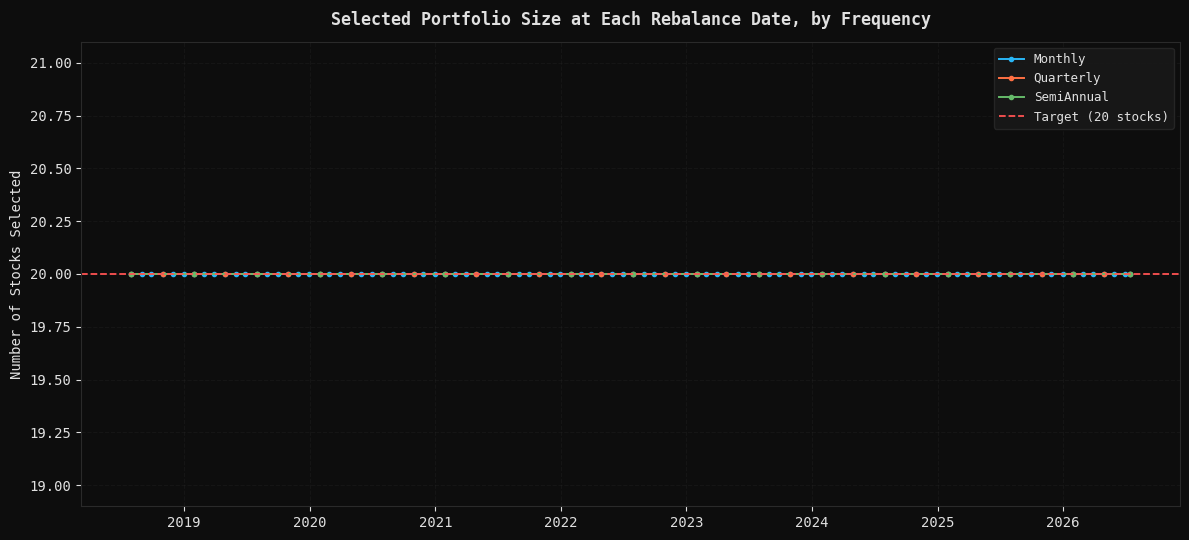

Saved -> .\output\03_portfolio_size_over_time.png


In [6]:
fig, ax = plt.subplots(figsize=(12, 5.5))
for i, freq_name in enumerate(REBAL_FREQ_STEP.keys()):
    sub = selection_log[selection_log['frequency'] == freq_name]
    ax.plot(sub['rebalance_date'], sub['n_selected'], color=COLORS[i], linewidth=1.4,
            marker='o', markersize=3, label=freq_name)

ax.axhline(TARGET_PORTFOLIO_SIZE, color=ACCENT2, linestyle='--', linewidth=1.3,
           label=f'Target ({TARGET_PORTFOLIO_SIZE} stocks)')
ax.set_title('Selected Portfolio Size at Each Rebalance Date, by Frequency',
              fontsize=12, fontweight='bold', color=TEXT_COLOR, pad=12)
ax.set_ylabel('Number of Stocks Selected')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
path = os.path.join(OUTPUT_DIR, '03_portfolio_size_over_time.png')
plt.savefig(path, dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print(f'Saved -> {path}')


### Cell 7 — Equal Weight Scheme

In [7]:
def equal_weights(selected_scores):
    """selected_scores: pd.Series indexed by ticker (composite scores, any values).
    Returns pd.Series of weights indexed by the same tickers, summing to 1."""
    n = len(selected_scores)
    return pd.Series(1.0 / n, index=selected_scores.index)


# Quick sanity check on one rebalance date
_sample_key = list(SELECTIONS.keys())[0]
_sample_ew = equal_weights(SELECTIONS[_sample_key])
print(f'Sample ({_sample_key[0]}, {_sample_key[1].date()}): '
      f'{len(_sample_ew)} stocks, weights sum to {_sample_ew.sum():.6f}, '
      f'each weight = {_sample_ew.iloc[0]:.4f}')


Sample (Monthly, 2018-07-31): 20 stocks, weights sum to 1.000000, each weight = 0.0500


### Cell 8 — True Equal Risk Contribution (ERC) Optimizer

Solved via `scipy.optimize` for weights where each stock contributes equally to total portfolio
risk -- not naive inverse-volatility weighting. Long-only (weights in [0, 1]), fully invested
(weights sum to 1), no leverage.

Covariance is estimated from the trailing 756 trading days of daily returns ending at each
rebalance date (matching the Max Drawdown/Beta window elsewhere in the project). If fewer than
`ERC_MIN_OBS` observations are available for a stock at a given rebalance date (only possible very
early in the backtest, or for a very recently listed stock with a short return history within the
selected Top 20), the optimizer falls back to Equal Weight for that (date, frequency) combination and
logs it explicitly -- it does not silently drop the stock or crash.

Covariance matrices with a high condition number (near-singular -- common when trailing history is
short relative to the number of selected stocks, or when several selected stocks are highly
collinear) are shrunk toward their diagonal (light regularisation) before optimization, and the event
is logged in `erc_diagnostics_log`.

In [8]:
from scipy.optimize import minimize

erc_diagnostics_rows = []


def estimate_covariance(tickers, rebalance_date, lookback=ERC_COV_LOOKBACK_DAYS):
    """Trailing covariance matrix (annualised) for the given tickers, using daily returns
    strictly before rebalance_date. Returns (cov_matrix_df, n_obs_used, was_shrunk,
    original_cond_number) -- the condition number returned is always the PRE-shrinkage value,
    so the diagnostic log shows how near-singular the raw estimate actually was, not the
    (necessarily well-conditioned) post-shrinkage result."""
    window = daily_returns.loc[:rebalance_date, tickers]
    window = window.iloc[:-1] if len(window) > 0 and window.index[-1] == rebalance_date else window
    window = window.tail(lookback)

    clean = window.dropna(how='any')
    if len(clean) < 2:
        return None, len(clean), False, np.nan

    cov = clean.cov().values * ANN_FACTOR
    was_shrunk = False
    original_cond_number = np.linalg.cond(cov)

    if original_cond_number > ERC_COND_NUMBER_FLAG:
        avg_var = np.mean(np.diag(cov))
        diag_target = np.eye(len(tickers)) * avg_var
        cov = (1 - ERC_SHRINKAGE_ALPHA) * cov + ERC_SHRINKAGE_ALPHA * diag_target
        was_shrunk = True

    return pd.DataFrame(cov, index=tickers, columns=tickers), len(clean), was_shrunk, original_cond_number


def erc_objective(w, cov_matrix):
    port_var = w @ cov_matrix @ w
    marginal_contrib = cov_matrix @ w
    risk_contrib = w * marginal_contrib
    target = port_var / len(w)
    return np.sum((risk_contrib - target) ** 2)


def solve_erc(selected_scores, rebalance_date):
    """Returns (weights: pd.Series, method_used: str) where method_used is 'ERC' or
    'EqualWeight_fallback'."""
    tickers = list(selected_scores.index)
    n = len(tickers)

    cov_df, n_obs, was_shrunk, cond_number = estimate_covariance(tickers, rebalance_date)

    if cov_df is None or n_obs < ERC_MIN_OBS:
        erc_diagnostics_rows.append({
            'rebalance_date': rebalance_date, 'n_stocks': n, 'n_obs_used': n_obs,
            'cond_number': np.nan, 'was_shrunk': False, 'fallback_to_ew': True,
            'optimizer_converged': np.nan,
        })
        return equal_weights(selected_scores), 'EqualWeight_fallback'

    cov = cov_df.values

    w0 = np.full(n, 1.0 / n)
    bounds = [(1e-6, 1.0) for _ in range(n)]
    constraints = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0}]

    result = minimize(
        erc_objective, w0, args=(cov,), method='SLSQP',
        bounds=bounds, constraints=constraints,
        options={'maxiter': ERC_MAX_ITER, 'ftol': 1e-12},
    )

    erc_diagnostics_rows.append({
        'rebalance_date': rebalance_date, 'n_stocks': n, 'n_obs_used': n_obs,
        'cond_number': cond_number, 'was_shrunk': was_shrunk, 'fallback_to_ew': False,
        'optimizer_converged': bool(result.success),
    })

    if not result.success:
        return equal_weights(selected_scores), 'EqualWeight_fallback'

    w = np.clip(result.x, 0, None)
    w = w / w.sum()
    return pd.Series(w, index=tickers), 'ERC'


# Quick sanity check on the same sample rebalance date used in Cell 7
_sample_erc_w, _sample_method = solve_erc(SELECTIONS[_sample_key], _sample_key[1])
print(f'Sample ({_sample_key[0]}, {_sample_key[1].date()}): method={_sample_method}, '
      f'weights sum to {_sample_erc_w.sum():.6f}, '
      f'min={_sample_erc_w.min():.4f}, max={_sample_erc_w.max():.4f}')


Sample (Monthly, 2018-07-31): method=ERC, weights sum to 1.000000, min=0.0280, max=0.0849


### Cell 9 — Build the Portfolio Holdings Panel (All Frequencies x Both Weighting Schemes)

In [9]:
holdings_rows = []

for (freq_name, rd), selected_scores in SELECTIONS.items():
    ew = equal_weights(selected_scores)
    for ticker, w in ew.items():
        holdings_rows.append({
            'rebalance_date': rd, 'frequency': freq_name,
            'weighting_scheme': 'EqualWeight', 'ticker': ticker, 'weight': w,
        })

    erc_w, erc_method = solve_erc(selected_scores, rd)
    for ticker, w in erc_w.items():
        holdings_rows.append({
            'rebalance_date': rd, 'frequency': freq_name,
            'weighting_scheme': 'ERC', 'ticker': ticker, 'weight': w,
        })

portfolio_holdings = pd.DataFrame(holdings_rows)
erc_diagnostics_log = pd.DataFrame(erc_diagnostics_rows)

print(f'Portfolio holdings panel: {portfolio_holdings.shape[0]} rows '
      f'({portfolio_holdings[["frequency", "weighting_scheme"]].drop_duplicates().shape[0]} '
      f'frequency x scheme combinations)')

_weight_sums = portfolio_holdings.groupby(['frequency', 'weighting_scheme', 'rebalance_date'])['weight'].sum()
_bad_sums = _weight_sums[(_weight_sums - 1.0).abs() > 1e-6]
print(f'Weight-sum sanity check: {len(_bad_sums)} / {len(_weight_sums)} '
      f'(frequency, scheme, date) groups do not sum to 1.0 (should be 0)')

n_shrunk = erc_diagnostics_log['was_shrunk'].sum()
n_fallback = erc_diagnostics_log['fallback_to_ew'].sum()
n_not_converged = (erc_diagnostics_log['optimizer_converged'] == False).sum()
print(f'ERC diagnostics: {n_shrunk} covariance matrices shrunk (near-singular), '
      f'{n_fallback} fell back to Equal Weight (insufficient history), '
      f'{n_not_converged} optimizer non-convergences (fell back to Equal Weight)')


Portfolio holdings panel: 5880 rows (6 frequency x scheme combinations)
Weight-sum sanity check: 0 / 294 (frequency, scheme, date) groups do not sum to 1.0 (should be 0)
ERC diagnostics: 65 covariance matrices shrunk (near-singular), 0 fell back to Equal Weight (insufficient history), 0 optimizer non-convergences (fell back to Equal Weight)


### Cell 10 — Diagnostic: Weight Distribution Sanity Checks (ERC vs Equal Weight)

Concentration is measured via the Herfindahl-Hirschman Index (HHI, sum of squared weights) and its
inverse, "effective number of stocks" (`1 / HHI`). Equal Weight over N stocks always has an effective
N of exactly N; ERC's effective N is expected to be somewhat lower (it tilts away from the highest-
volatility / most-correlated names), which is the intended behaviour, not a flaw.

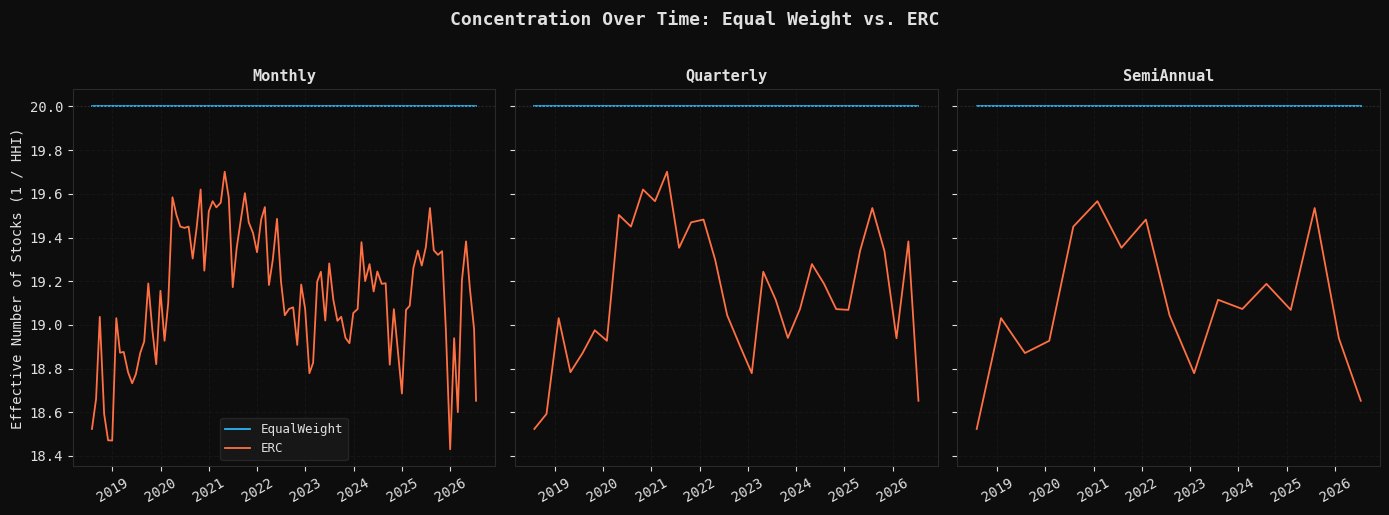

Saved -> .\output\03_weight_concentration_ew_vs_erc.png

Median effective N by frequency and scheme:
frequency   weighting_scheme
Monthly     ERC                 19.17
            EqualWeight         20.00
Quarterly   ERC                 19.11
            EqualWeight         20.00
SemiAnnual  ERC                 19.07
            EqualWeight         20.00


In [10]:
def herfindahl(weights):
    return np.sum(weights ** 2)


concentration_rows = []
for (freq_name, scheme), grp in portfolio_holdings.groupby(['frequency', 'weighting_scheme']):
    for rd, sub in grp.groupby('rebalance_date'):
        hhi = herfindahl(sub['weight'].values)
        concentration_rows.append({
            'frequency': freq_name, 'weighting_scheme': scheme, 'rebalance_date': rd,
            'hhi': hhi, 'effective_n': 1.0 / hhi, 'max_weight': sub['weight'].max(),
        })

concentration_df = pd.DataFrame(concentration_rows)

fig, axes = plt.subplots(1, len(REBAL_FREQ_STEP), figsize=(14, 5), sharey=True)
for ax, freq_name in zip(axes, REBAL_FREQ_STEP.keys()):
    for i, scheme in enumerate(WEIGHTING_SCHEMES):
        sub = concentration_df[(concentration_df['frequency'] == freq_name) &
                                (concentration_df['weighting_scheme'] == scheme)]
        ax.plot(sub['rebalance_date'], sub['effective_n'], color=COLORS[i], linewidth=1.3,
                label=scheme)
    ax.set_title(freq_name, fontsize=11, fontweight='bold', color=TEXT_COLOR)
    ax.axhline(TARGET_PORTFOLIO_SIZE, color=GRID_COLOR, linestyle=':', linewidth=1.0)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=30)

axes[0].set_ylabel('Effective Number of Stocks (1 / HHI)')
axes[0].legend(fontsize=9)
fig.suptitle('Concentration Over Time: Equal Weight vs. ERC', fontsize=13, fontweight='bold',
             color=TEXT_COLOR, y=1.02)
plt.tight_layout()
path = os.path.join(OUTPUT_DIR, '03_weight_concentration_ew_vs_erc.png')
plt.savefig(path, dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print(f'Saved -> {path}')

print()
print('Median effective N by frequency and scheme:')
print(concentration_df.groupby(['frequency', 'weighting_scheme'])['effective_n']
      .median().round(2).to_string())


### Cell 11 — Diagnostic: ERC Optimizer Robustness (Near-Singular Covariance & Fallbacks)

Surfaces every (frequency, rebalance_date) combination where the ERC optimizer either (a) fell back
to Equal Weight because too few return observations were available, (b) required covariance
shrinkage because the raw covariance matrix was near-singular, or (c) failed to converge. This is the
explicit stress-test the project's testing discipline requires -- these events are logged, not
hidden.

In [11]:
flagged = erc_diagnostics_log[
    erc_diagnostics_log['was_shrunk'] |
    erc_diagnostics_log['fallback_to_ew'] |
    (erc_diagnostics_log['optimizer_converged'] == False)
].copy()

print(f'Flagged ERC events: {len(flagged)} / {len(erc_diagnostics_log)} '
      f'(frequency, rebalance_date) combinations')

if len(flagged) > 0:
    print()
    print(flagged.sort_values('rebalance_date').to_string(index=False))
    print()
    print('These typically cluster at the very start of the backtest window (limited trailing '
          'history right after BACKTEST_START), which is expected -- if they appear scattered '
          'throughout the backtest instead, that would warrant investigation.')
else:
    print('No near-singular covariance matrices, insufficient-history fallbacks, or optimizer '
          'non-convergences across the full backtest window.')


Flagged ERC events: 65 / 148 (frequency, rebalance_date) combinations

rebalance_date  n_stocks  n_obs_used  cond_number  was_shrunk  fallback_to_ew  optimizer_converged
    2018-08-31        20         756 2.904550e+18        True           False                 True
    2018-09-28        20         756 2.831811e+16        True           False                 True
    2018-10-31        20         756 1.653809e+16        True           False                 True
    2018-10-31        20         756 1.653809e+16        True           False                 True
    2018-11-30        20         756 1.594140e+16        True           False                 True
    2018-12-31        20         756 1.288571e+16        True           False                 True
    2019-01-31        20         638 6.361915e+16        True           False                 True
    2019-01-31        20         638 6.361915e+16        True           False                 True
    2019-01-31        20         638 6

### Cell 12 — Save Portfolio Holdings Panel & Diagnostics to data/

In [12]:
portfolio_holdings.to_csv(os.path.join(DATA_DIR, 'portfolio_holdings.csv'), index=False)
selection_log.to_csv(os.path.join(DATA_DIR, 'portfolio_selection_log.csv'), index=False)
erc_diagnostics_log.to_csv(os.path.join(DATA_DIR, 'erc_diagnostics_log.csv'), index=False)
concentration_df.to_csv(os.path.join(DATA_DIR, 'portfolio_concentration.csv'), index=False)

print('Saved to data/:')
for f in ['portfolio_holdings.csv', 'portfolio_selection_log.csv',
          'erc_diagnostics_log.csv', 'portfolio_concentration.csv']:
    print(f'  {f}')

print()
print('=' * 60)
print('NOTEBOOK 03 -- COMPLETE')
print('=' * 60)
print(f'  Frequencies              : {list(REBAL_FREQ_STEP.keys())}')
print(f'  Weighting schemes        : {WEIGHTING_SCHEMES}')
print(f'  Target portfolio size    : {TARGET_PORTFOLIO_SIZE} stocks')
print(f'  Under-target rebalances  : {n_under_target} / {len(selection_log)}')
print(f'  ERC fallbacks / shrinkage: {n_fallback} fallback, {n_shrunk} shrunk, '
      f'{n_not_converged} non-converged')
print()
print('  Charts in output/:')
for f in ['03_portfolio_size_over_time.png', '03_weight_concentration_ew_vs_erc.png']:
    print(f'    {f}')
print()
print('  Next -> Notebook 04: Walk-Forward Backtest')


Saved to data/:
  portfolio_holdings.csv
  portfolio_selection_log.csv
  erc_diagnostics_log.csv
  portfolio_concentration.csv

NOTEBOOK 03 -- COMPLETE
  Frequencies              : ['Monthly', 'Quarterly', 'SemiAnnual']
  Weighting schemes        : ['EqualWeight', 'ERC']
  Target portfolio size    : 20 stocks
  Under-target rebalances  : 0 / 147
  ERC fallbacks / shrinkage: 0 fallback, 65 shrunk, 0 non-converged

  Charts in output/:
    03_portfolio_size_over_time.png
    03_weight_concentration_ew_vs_erc.png

  Next -> Notebook 04: Walk-Forward Backtest


---
## Portfolio Research Section

**This entire section is for research interpretation and portfolio review only.** Every output below
(ranked-universe panel, tables, charts, turnover logs, selection-frequency stats) is computed strictly
*after* the portfolio construction logic above (Cells 1-12) has already run and been saved. Nothing in
this section feeds back into stock selection, weighting, or the Top-20 cutoff -- it exists purely to
give a portfolio manager an interpretable window into *why* the portfolio looks the way it does at any
given rebalance.

**Sector/Industry data source (confirmed with the user):** the project's original plan (see
`PROJECT_STATE.md` Section 3.6) deferred yfinance `sector`/`industry` fetching to Notebook 05. That
work is brought forward here instead, cached once per ticker to `data/ticker_sector_map.csv` so NB05
can reuse it without re-fetching. Coverage is expected to be imperfect for some NSE mid-caps (a known,
disclosed yfinance limitation, not a bug) -- any ticker with missing data is explicitly labelled
`'Unknown'`, never silently dropped.

### Cell R1 — Dark-Themed Table Renderer (Shared Helper for This Section)

In [13]:
def render_dark_table(df, title, filename, col_widths=None, highlight_rows=None,
                       figsize=None, header_color=ACCENT):
    """Renders a pandas DataFrame as a dark-themed matplotlib table, saves it to output/,
    and displays it inline. highlight_rows (optional): iterable of row indices (0-based, into
    df, not including the header) to tint slightly differently (e.g. to mark ERC-fallback rows)."""
    n_rows, n_cols = df.shape
    fig_w = figsize[0] if figsize else max(9, 1.35 * n_cols)
    fig_h = figsize[1] if figsize else max(1.6, 0.42 * n_rows + 1.3)
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    ax.axis('off')

    tbl = ax.table(cellText=df.values, colLabels=df.columns, cellLoc='center', loc='center',
                   colWidths=col_widths)
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(9.5)
    tbl.scale(1, 1.7)

    highlight_rows = set(highlight_rows) if highlight_rows else set()
    for (row, col), cell in tbl.get_celld().items():
        cell.set_edgecolor(GRID_COLOR)
        cell.set_linewidth(0.6)
        if row == 0:
            cell.set_facecolor(header_color)
            cell.set_text_props(weight='bold', color=DARK_BG, fontsize=10)
        else:
            data_row = row - 1
            if data_row in highlight_rows:
                cell.set_facecolor('#22331F')
            else:
                cell.set_facecolor(PANEL_BG if data_row % 2 == 0 else DARK_BG)
            cell.set_text_props(color=TEXT_COLOR)

    ax.set_title(title, fontsize=13, fontweight='bold', color=TEXT_COLOR, pad=16)
    plt.tight_layout()
    path = os.path.join(OUTPUT_DIR, filename)
    plt.savefig(path, dpi=150, bbox_inches='tight', facecolor=DARK_BG)
    plt.show()
    print(f'Saved -> {path}')
    return path


print('Dark table renderer ready.')


Dark table renderer ready.


### Cell R2 — Sector & Industry Metadata (yfinance, Cached Per Ticker)

Sector and industry do not change per rebalance date, so this is fetched (or loaded from cache) once
per ticker in the master universe, not once per rebalance date.

In [14]:
import yfinance as yf

SECTOR_MAP_FILE = os.path.join(DATA_DIR, 'ticker_sector_map.csv')

if os.path.exists(SECTOR_MAP_FILE):
    sector_map = pd.read_csv(SECTOR_MAP_FILE, index_col='ticker')
    print(f'Loaded cached sector/industry map for {len(sector_map)} tickers '
          f'from {SECTOR_MAP_FILE}')
else:
    print(f'Fetching sector/industry for {len(master_universe)} tickers via yfinance ...')
    sector_rows = []
    for i, t in enumerate(master_universe):
        try:
            info = yf.Ticker(t).info
            sector = info.get('sector') or 'Unknown'
            industry = info.get('industry') or 'Unknown'
        except Exception:
            sector, industry = 'Unknown', 'Unknown'
        sector_rows.append({'ticker': t, 'sector': sector, 'industry': industry})
        if (i + 1) % 25 == 0:
            print(f'  ... {i + 1} / {len(master_universe)}')

    sector_map = pd.DataFrame(sector_rows).set_index('ticker')
    sector_map.to_csv(SECTOR_MAP_FILE)
    print(f'Saved sector/industry map -> {SECTOR_MAP_FILE}')

n_unknown_sector = (sector_map['sector'] == 'Unknown').sum()
print(f'Sector coverage: {len(sector_map) - n_unknown_sector} / {len(sector_map)} tickers '
      f'have a known sector ({n_unknown_sector} Unknown -- disclosed, not hidden; yfinance '
      f'sector/industry coverage is known to be patchy for some NSE mid-caps).')


Fetching sector/industry for 404 tickers via yfinance ...
  ... 25 / 404


HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: BAJAJAUTO.NS"}}}


  ... 50 / 404
  ... 75 / 404
  ... 100 / 404
  ... 125 / 404
  ... 150 / 404
  ... 175 / 404
  ... 200 / 404
  ... 225 / 404
  ... 250 / 404


HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: NAMINDIA.NS"}}}


  ... 275 / 404
  ... 300 / 404
  ... 325 / 404
  ... 350 / 404
  ... 375 / 404
  ... 400 / 404
Saved sector/industry map -> .\data\ticker_sector_map.csv
Sector coverage: 383 / 404 tickers have a known sector (21 Unknown -- disclosed, not hidden; yfinance sector/industry coverage is known to be patchy for some NSE mid-caps).


### Cell R3 — AMFI Large/Mid Classification, As-Of Each Rebalance Date

Unlike sector/industry, AMFI classification genuinely changes over time (a stock can move from Mid
Cap to Large Cap between AMFI snapshots), so this must be looked up "as of" each rebalance date -- the
most recent AMFI snapshot on or before that date -- rather than fetched once per ticker. Reuses NB01's
`amfi_membership_matrix.csv`; no new download required.

In [15]:
amfi_membership_matrix = pd.read_csv(
    os.path.join(DATA_DIR, 'amfi_membership_matrix.csv'), index_col=0
)
amfi_membership_matrix.columns = pd.to_datetime(amfi_membership_matrix.columns)


def amfi_class_asof_series(rebalance_date):
    """Returns a pd.Series indexed by ticker, giving each ticker's AMFI classification
    ('Large Cap' / 'Mid Cap') as of the most recent snapshot on or before rebalance_date.
    Tickers with no snapshot yet available, or not in the matrix, are 'Unknown'."""
    valid_snaps = amfi_membership_matrix.columns[amfi_membership_matrix.columns <= rebalance_date]
    if len(valid_snaps) == 0:
        return pd.Series('Unknown', index=amfi_membership_matrix.index)
    latest_snap = valid_snaps.max()
    return amfi_membership_matrix[latest_snap].fillna('Unknown')


_sample_asof = amfi_class_asof_series(monthly_dates[-1])
print(f'Sample as-of classification ({monthly_dates[-1].date()}): '
      f'{_sample_asof.value_counts().to_dict()}')


Sample as-of classification (2026-07-15): {'Unknown': 193, 'Mid Cap': 148, 'Large Cap': 100}


### Cell R4 — Build the Full Ranked-Universe Panel (Research Only)

For every (frequency, rebalance date), every *eligible* stock (not just the selected Top 20) is
included with its rank, composite score, individual factor z-scores, sector, industry, AMFI
classification, both weighting schemes (populated only for selected stocks; `NaN` otherwise -- an
unselected stock has no weight, that is not a missing-data bug), and an explicit selection flag. This
is strictly a reporting view built from data already produced by Cells 1-12 above.

In [16]:
ranked_universe_rows = []

for freq_name, dates in REBAL_DATES_BY_FREQ.items():
    for rd in dates:
        eligible_scores = composite_score_panel.loc[rd].dropna().sort_values(ascending=False)
        if len(eligible_scores) == 0:
            continue

        factor_row = factor_panel_long[factor_panel_long['rebalance_date'] == rd].set_index('ticker')
        amfi_asof = amfi_class_asof_series(rd)

        selected_scores = SELECTIONS[(freq_name, rd)]
        selected_tickers = set(selected_scores.index)
        ew_weights = equal_weights(selected_scores) if len(selected_scores) > 0 else pd.Series(dtype=float)

        erc_weights_row = portfolio_holdings[
            (portfolio_holdings['frequency'] == freq_name) &
            (portfolio_holdings['rebalance_date'] == rd) &
            (portfolio_holdings['weighting_scheme'] == 'ERC')
        ].set_index('ticker')['weight']

        for rank, (ticker, score) in enumerate(eligible_scores.items(), start=1):
            f_row = factor_row.loc[ticker] if ticker in factor_row.index else None
            ranked_universe_rows.append({
                'frequency':           freq_name,
                'rebalance_date':      rd,
                'rank':                rank,
                'ticker':              ticker,
                'composite_score':     score,
                'momentum_z':          f_row['momentum_z'] if f_row is not None else np.nan,
                'low_vol_z':           f_row['low_vol_z'] if f_row is not None else np.nan,
                'max_dd_z':            f_row['max_dd_z'] if f_row is not None else np.nan,
                'beta_z':              f_row['beta_z'] if f_row is not None else np.nan,
                'sector':              sector_map.loc[ticker, 'sector'] if ticker in sector_map.index else 'Unknown',
                'industry':            sector_map.loc[ticker, 'industry'] if ticker in sector_map.index else 'Unknown',
                'amfi_classification': amfi_asof.get(ticker, 'Unknown'),
                'equal_weight':        ew_weights.get(ticker, np.nan),
                'erc_weight':          erc_weights_row.get(ticker, np.nan),
                'selected_top20':      ticker in selected_tickers,
            })

ranked_universe_panel = pd.DataFrame(ranked_universe_rows)

print(f'Ranked-universe panel: {ranked_universe_panel.shape[0]} rows '
      f'(all eligible stocks, all frequencies, all rebalance dates)')
print(f'  Selected (Top 20) rows : {ranked_universe_panel["selected_top20"].sum()}')
print(f'  Non-selected rows      : {(~ranked_universe_panel["selected_top20"]).sum()}')


Ranked-universe panel: 49071 rows (all eligible stocks, all frequencies, all rebalance dates)
  Selected (Top 20) rows : 2940
  Non-selected rows      : 46131


### Cell R5 — Save the Ranked-Universe Panel

In [17]:
ranked_universe_panel.to_csv(os.path.join(DATA_DIR, 'ranked_universe_panel.csv'), index=False)
print(f'Saved -> {os.path.join(DATA_DIR, "ranked_universe_panel.csv")}')
print(f'  {ranked_universe_panel.shape[0]} rows x {ranked_universe_panel.shape[1]} columns')


Saved -> .\data\ranked_universe_panel.csv
  49071 rows x 15 columns


### Cell R6 — Research Output 1: Top-20 Portfolio Table (Latest Rebalance, per Frequency)

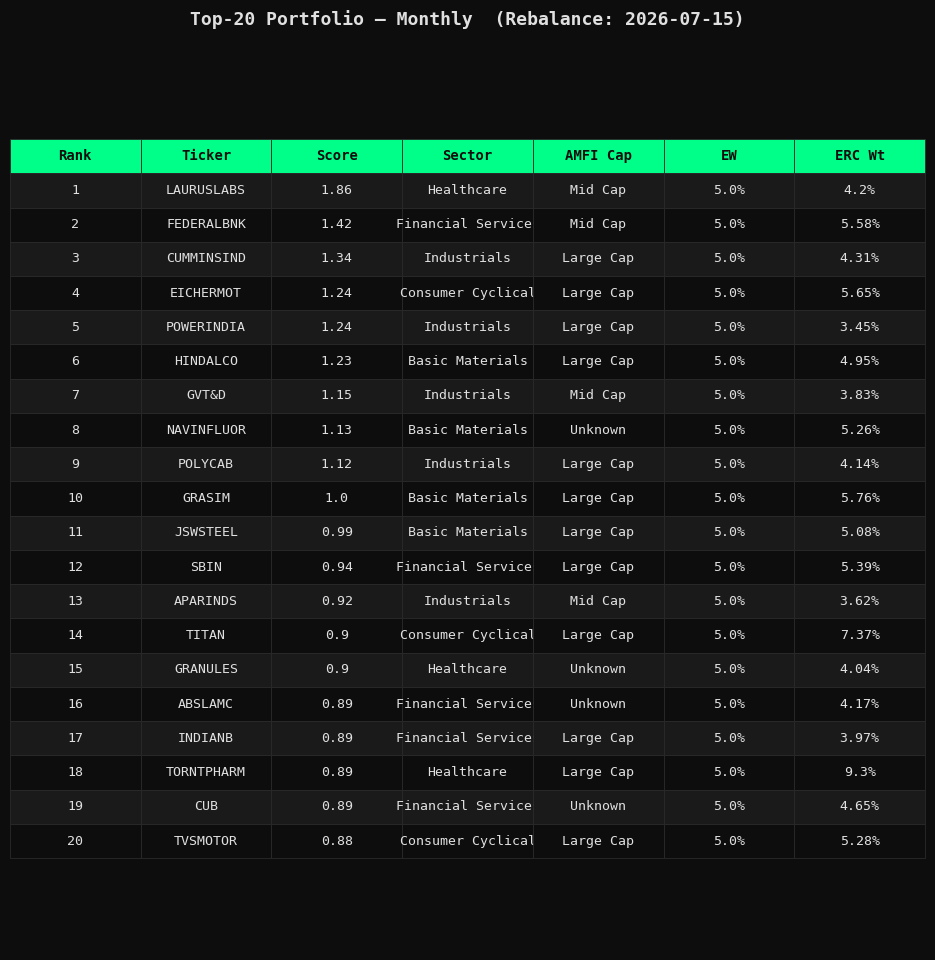

Saved -> .\output\03_research_top20_monthly.png


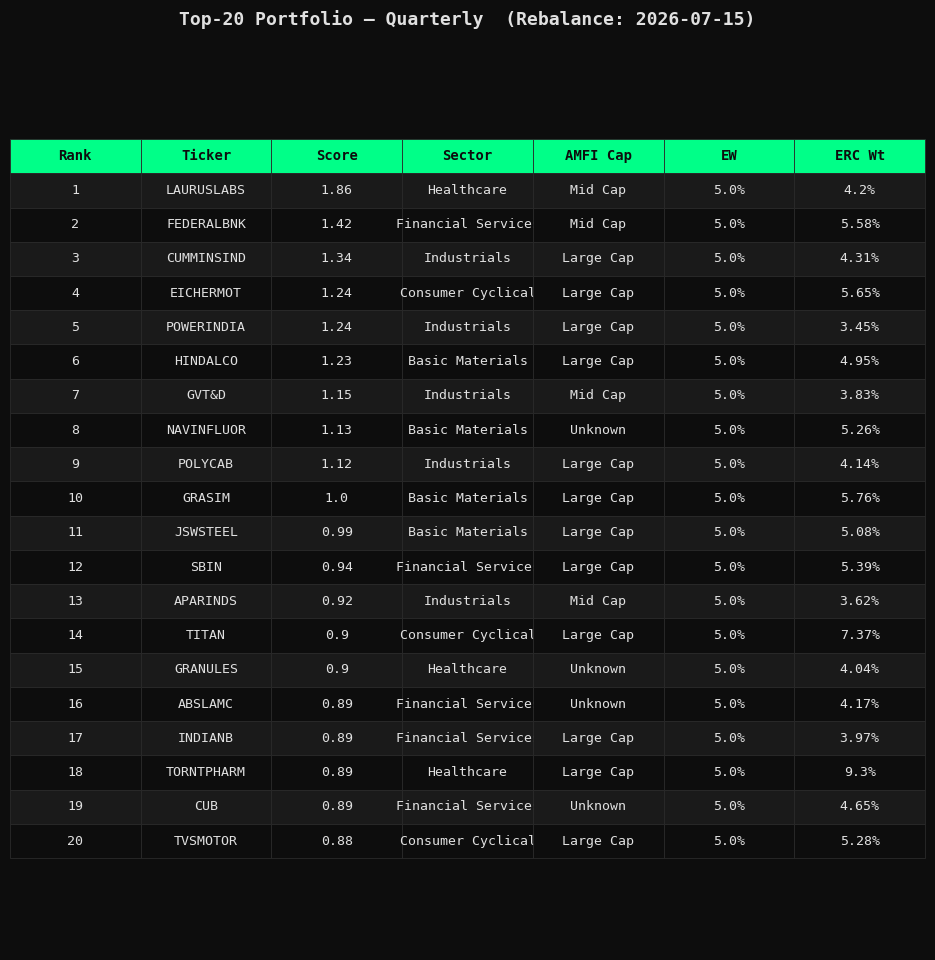

Saved -> .\output\03_research_top20_quarterly.png


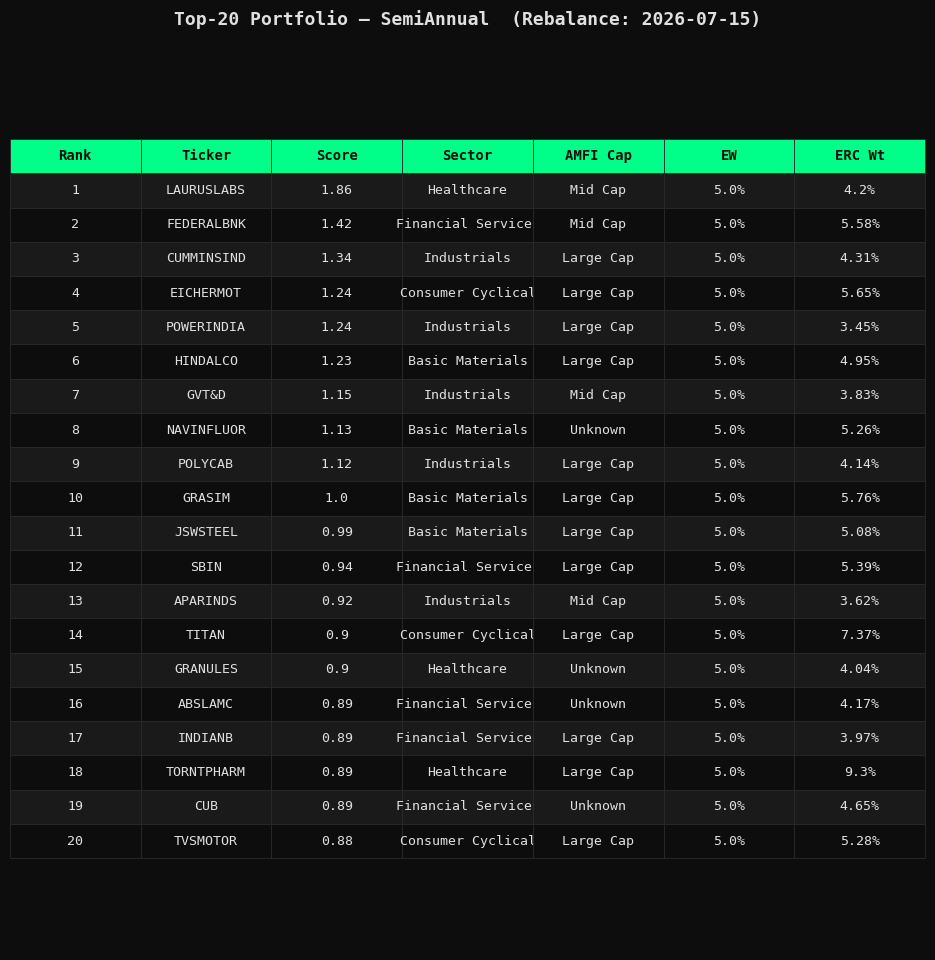

Saved -> .\output\03_research_top20_semiannual.png


In [18]:
def format_top20_table(freq_name):
    rd = REBAL_DATES_BY_FREQ[freq_name][-1]
    sub = ranked_universe_panel[
        (ranked_universe_panel['frequency'] == freq_name) &
        (ranked_universe_panel['rebalance_date'] == rd) &
        (ranked_universe_panel['selected_top20'])
    ].sort_values('rank').copy()

    display_df = pd.DataFrame({
        'Rank':      sub['rank'].astype(int),
        'Ticker':    sub['ticker'].str.replace('.NS', '', regex=False),
        'Score':     sub['composite_score'].round(2),
        'Sector':    sub['sector'],
        'AMFI Cap':  sub['amfi_classification'],
        'EW':        (sub['equal_weight'] * 100).round(2).astype(str) + '%',
        'ERC Wt':    (sub['erc_weight'] * 100).round(2).astype(str) + '%',
    })
    return rd, display_df


for freq_name in REBAL_FREQ_STEP.keys():
    rd, table = format_top20_table(freq_name)
    render_dark_table(
        table, f'Top-20 Portfolio — {freq_name}  (Rebalance: {rd.date()})',
        f'03_research_top20_{freq_name.lower()}.png'
    )


### Cell R7 — Research Output 2: Buffer / Watchlist (Ranks 21-30, per Frequency)

The buffer zone -- stocks just outside the cutoff -- is often as informative to a PM as the portfolio
itself: it shows which names are "next in line" if a held stock's score deteriorates.

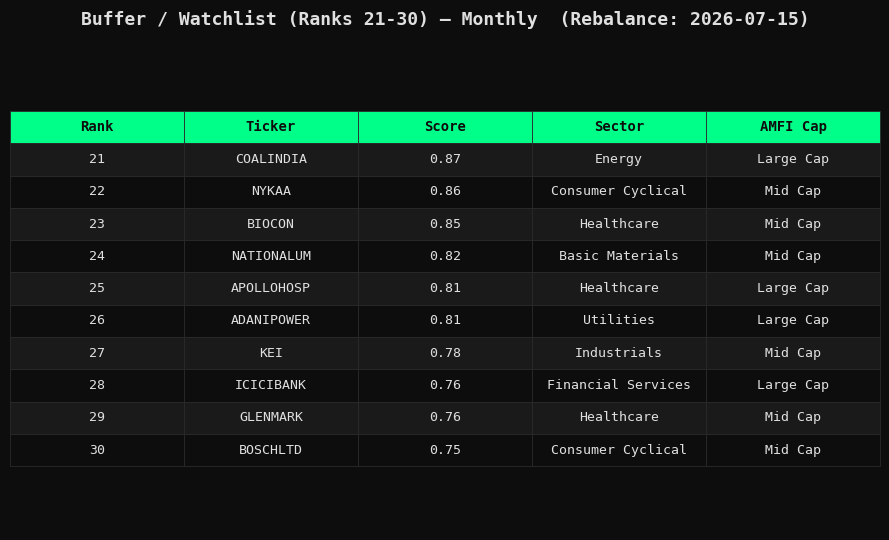

Saved -> .\output\03_research_buffer_monthly.png


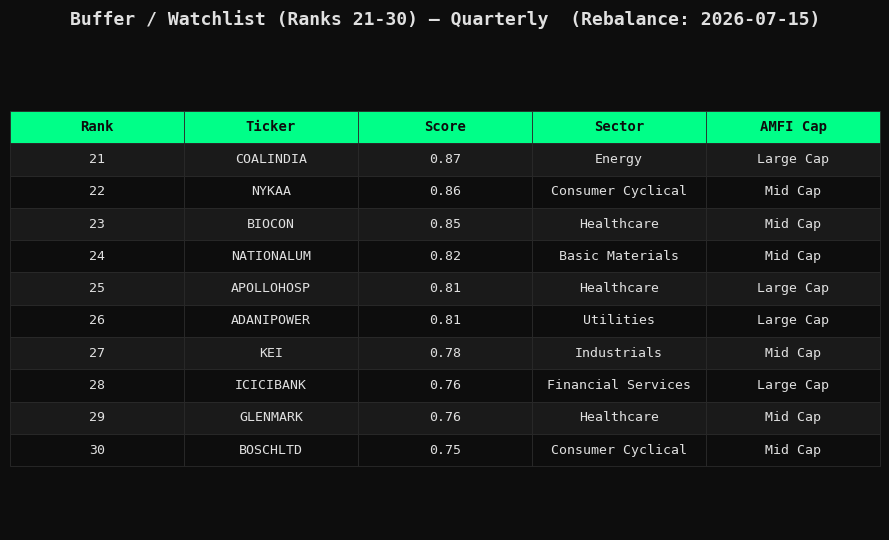

Saved -> .\output\03_research_buffer_quarterly.png


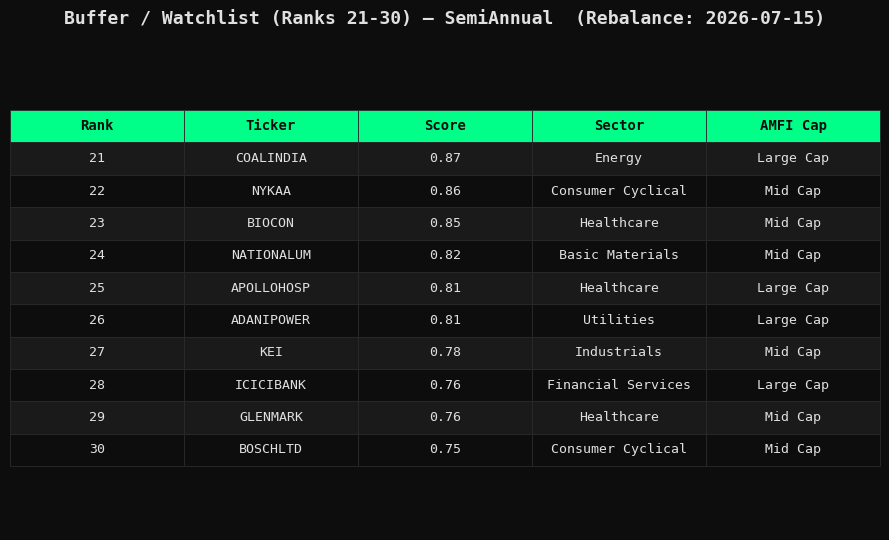

Saved -> .\output\03_research_buffer_semiannual.png


In [19]:
def format_buffer_table(freq_name):
    rd = REBAL_DATES_BY_FREQ[freq_name][-1]
    sub = ranked_universe_panel[
        (ranked_universe_panel['frequency'] == freq_name) &
        (ranked_universe_panel['rebalance_date'] == rd) &
        (ranked_universe_panel['rank'] >= BUFFER_RANK_START) &
        (ranked_universe_panel['rank'] <= BUFFER_RANK_END)
    ].sort_values('rank').copy()

    display_df = pd.DataFrame({
        'Rank':     sub['rank'].astype(int),
        'Ticker':   sub['ticker'].str.replace('.NS', '', regex=False),
        'Score':    sub['composite_score'].round(2),
        'Sector':   sub['sector'],
        'AMFI Cap': sub['amfi_classification'],
    })
    return rd, display_df


for freq_name in REBAL_FREQ_STEP.keys():
    rd, table = format_buffer_table(freq_name)
    if len(table) == 0:
        print(f'{freq_name}: no stocks in the rank {BUFFER_RANK_START}-{BUFFER_RANK_END} '
              f'buffer zone at {rd.date()} (eligible universe smaller than {BUFFER_RANK_START}).')
        continue
    render_dark_table(
        table, f'Buffer / Watchlist (Ranks {BUFFER_RANK_START}-{BUFFER_RANK_END}) — '
               f'{freq_name}  (Rebalance: {rd.date()})',
        f'03_research_buffer_{freq_name.lower()}.png'
    )


### Cell R8 — Research Output 3: Sector Allocation of the Selected Portfolio

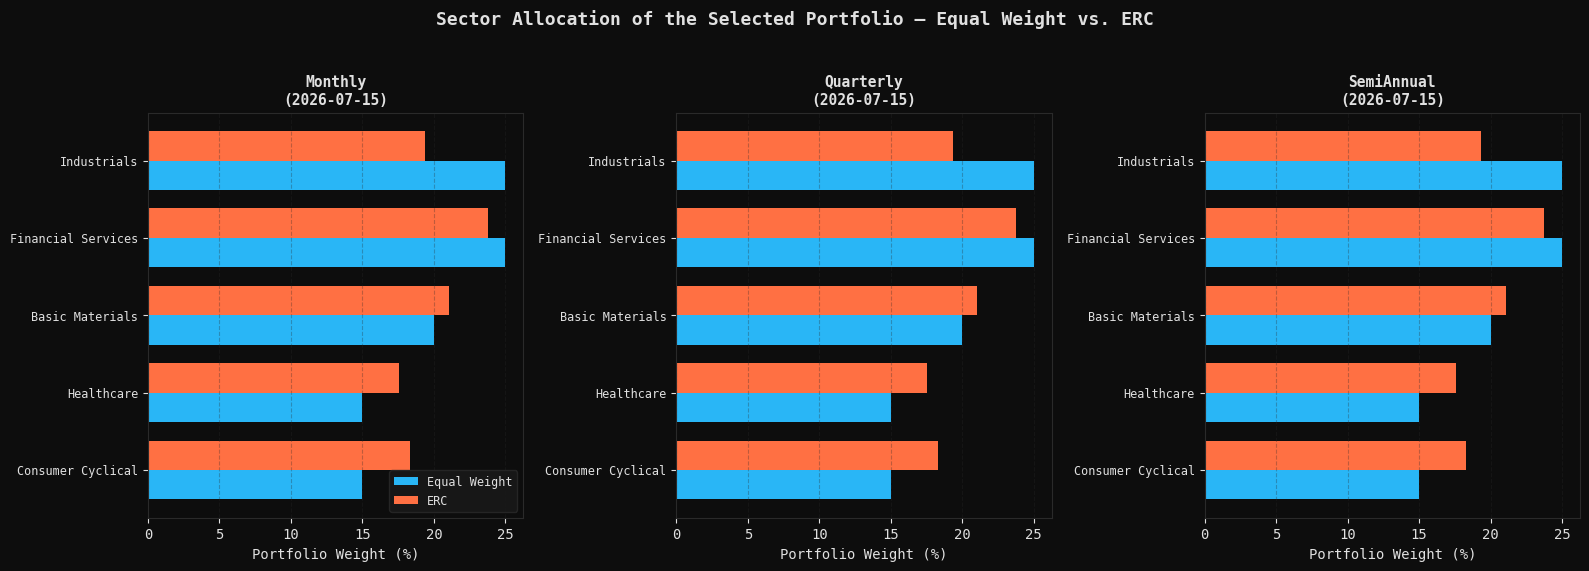

Saved -> .\output\03_research_sector_allocation.png


In [20]:
fig, axes = plt.subplots(1, len(REBAL_FREQ_STEP), figsize=(16, 5.5), sharey=False)

sector_alloc_rows = []
for ax, freq_name in zip(axes, REBAL_FREQ_STEP.keys()):
    rd = REBAL_DATES_BY_FREQ[freq_name][-1]
    sub = ranked_universe_panel[
        (ranked_universe_panel['frequency'] == freq_name) &
        (ranked_universe_panel['rebalance_date'] == rd) &
        (ranked_universe_panel['selected_top20'])
    ]

    by_sector = sub.groupby('sector')[['equal_weight', 'erc_weight']].sum().sort_values(
        'equal_weight', ascending=True
    )
    for sector, r in by_sector.iterrows():
        sector_alloc_rows.append({
            'frequency': freq_name, 'rebalance_date': rd, 'sector': sector,
            'equal_weight_allocation': r['equal_weight'], 'erc_weight_allocation': r['erc_weight'],
        })

    y_pos = np.arange(len(by_sector))
    ax.barh(y_pos - 0.19, by_sector['equal_weight'] * 100, height=0.38,
            color=COLORS[0], label='Equal Weight')
    ax.barh(y_pos + 0.19, by_sector['erc_weight'] * 100, height=0.38,
            color=COLORS[1], label='ERC')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(by_sector.index, fontsize=8.5)
    ax.set_xlabel('Portfolio Weight (%)')
    ax.set_title(f'{freq_name}\n({rd.date()})', fontsize=10.5, fontweight='bold', color=TEXT_COLOR)
    ax.grid(True, axis='x', alpha=0.3)

axes[0].legend(fontsize=8.5, loc='lower right')
fig.suptitle('Sector Allocation of the Selected Portfolio — Equal Weight vs. ERC',
             fontsize=13, fontweight='bold', color=TEXT_COLOR, y=1.03)
plt.tight_layout()
path = os.path.join(OUTPUT_DIR, '03_research_sector_allocation.png')
plt.savefig(path, dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print(f'Saved -> {path}')

sector_allocation_df = pd.DataFrame(sector_alloc_rows)


### Cell R9 — Research Output 4: Large vs. Mid Cap Allocation

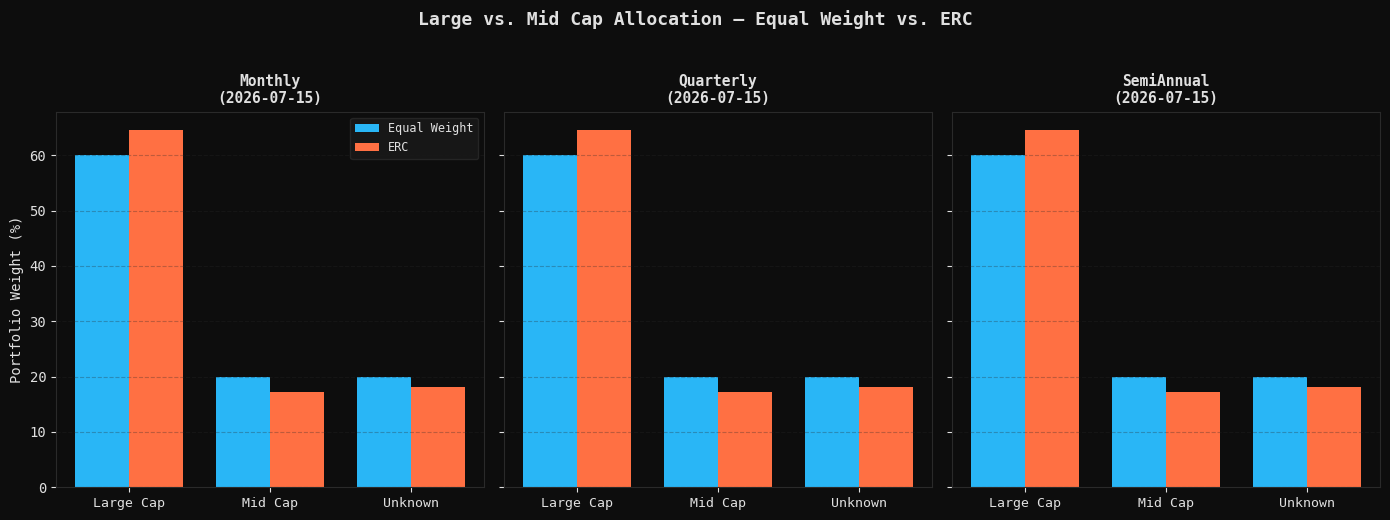

Saved -> .\output\03_research_capclass_allocation.png


In [21]:
fig, axes = plt.subplots(1, len(REBAL_FREQ_STEP), figsize=(14, 5), sharey=True)

capclass_alloc_rows = []
for ax, freq_name in zip(axes, REBAL_FREQ_STEP.keys()):
    rd = REBAL_DATES_BY_FREQ[freq_name][-1]
    sub = ranked_universe_panel[
        (ranked_universe_panel['frequency'] == freq_name) &
        (ranked_universe_panel['rebalance_date'] == rd) &
        (ranked_universe_panel['selected_top20'])
    ]

    by_cap = sub.groupby('amfi_classification')[['equal_weight', 'erc_weight']].sum()
    for cap_class, r in by_cap.iterrows():
        capclass_alloc_rows.append({
            'frequency': freq_name, 'rebalance_date': rd, 'amfi_classification': cap_class,
            'equal_weight_allocation': r['equal_weight'], 'erc_weight_allocation': r['erc_weight'],
        })

    x_pos = np.arange(len(by_cap))
    ax.bar(x_pos - 0.19, by_cap['equal_weight'] * 100, width=0.38, color=COLORS[0], label='Equal Weight')
    ax.bar(x_pos + 0.19, by_cap['erc_weight'] * 100, width=0.38, color=COLORS[1], label='ERC')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(by_cap.index, fontsize=9.5)
    ax.set_title(f'{freq_name}\n({rd.date()})', fontsize=10.5, fontweight='bold', color=TEXT_COLOR)
    ax.grid(True, axis='y', alpha=0.3)

axes[0].set_ylabel('Portfolio Weight (%)')
axes[0].legend(fontsize=8.5)
fig.suptitle('Large vs. Mid Cap Allocation — Equal Weight vs. ERC', fontsize=13, fontweight='bold',
             color=TEXT_COLOR, y=1.03)
plt.tight_layout()
path = os.path.join(OUTPUT_DIR, '03_research_capclass_allocation.png')
plt.savefig(path, dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print(f'Saved -> {path}')

capclass_allocation_df = pd.DataFrame(capclass_alloc_rows)


### Cell R10 — Research Output 5: Stocks Added & Removed at Each Rebalance (Top-20 Only)

Tracks turnover in the *selected* Top-20 portfolio only (per the user's confirmed scope), not the
full ranked universe -- i.e. what actually changed in the portfolio a PM would be holding.

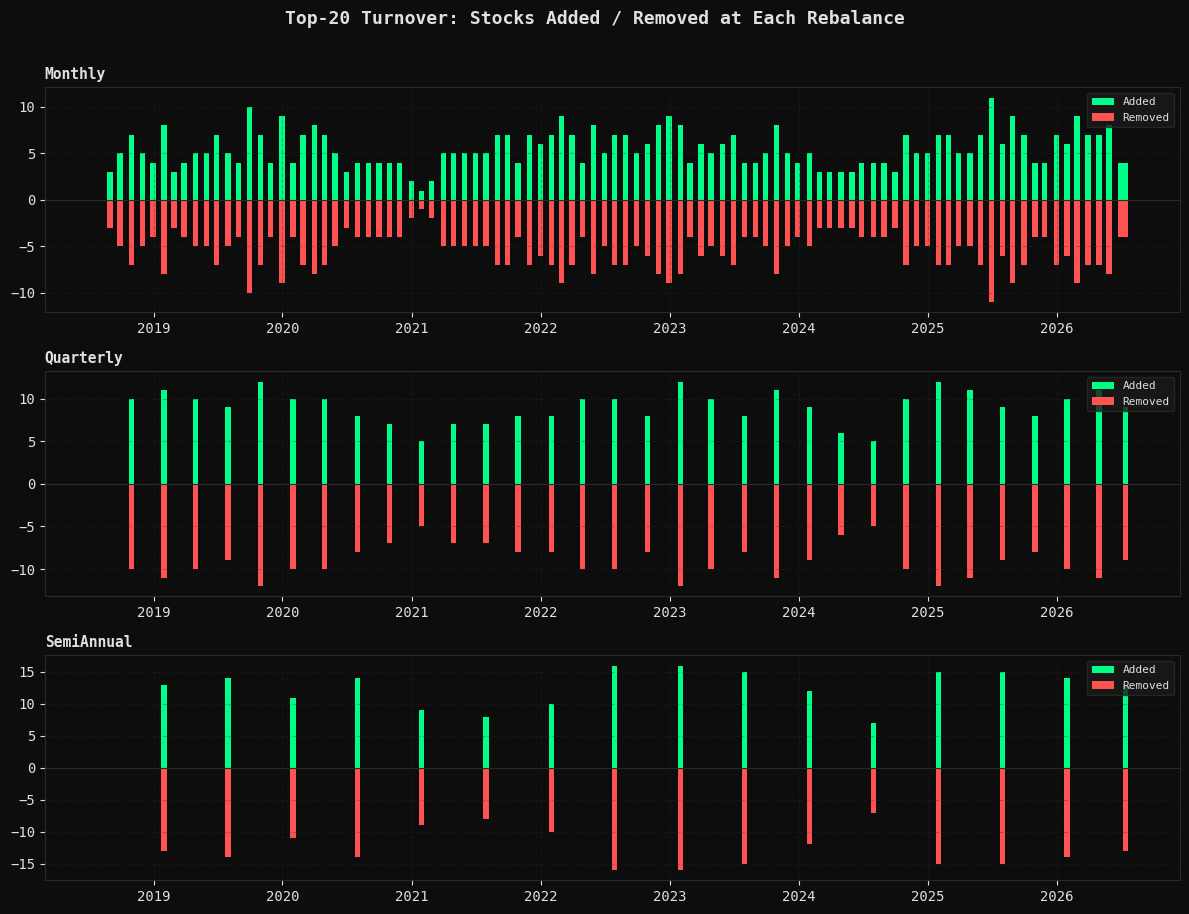

Saved -> .\output\03_research_turnover.png

Median names added / removed per rebalance, by frequency:
            n_added  n_removed
frequency                     
Monthly         5.0        5.0
Quarterly       9.0        9.0
SemiAnnual     13.0       13.0


In [22]:
turnover_rows = []

for freq_name, dates in REBAL_DATES_BY_FREQ.items():
    prev_holdings = None
    for rd in dates:
        current_holdings = set(SELECTIONS[(freq_name, rd)].index)
        if prev_holdings is None:
            added, removed = set(), set()
        else:
            added = current_holdings - prev_holdings
            removed = prev_holdings - current_holdings
        turnover_rows.append({
            'frequency': freq_name, 'rebalance_date': rd,
            'n_added': len(added), 'n_removed': len(removed),
            'added_tickers': ', '.join(sorted(t.replace('.NS', '') for t in added)),
            'removed_tickers': ', '.join(sorted(t.replace('.NS', '') for t in removed)),
        })
        prev_holdings = current_holdings

turnover_log = pd.DataFrame(turnover_rows)

fig, axes = plt.subplots(len(REBAL_FREQ_STEP), 1, figsize=(12, 9), sharex=False)
for ax, freq_name in zip(axes, REBAL_FREQ_STEP.keys()):
    sub = turnover_log[turnover_log['frequency'] == freq_name]
    ax.bar(sub['rebalance_date'], sub['n_added'], color=ACCENT, label='Added', width=15,
           align='center')
    ax.bar(sub['rebalance_date'], -sub['n_removed'], color=ACCENT2, label='Removed', width=15,
           align='center')
    ax.axhline(0, color=GRID_COLOR, linewidth=0.8)
    ax.set_title(freq_name, fontsize=10.5, fontweight='bold', color=TEXT_COLOR, loc='left')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, loc='upper right')

fig.suptitle('Top-20 Turnover: Stocks Added / Removed at Each Rebalance', fontsize=13,
             fontweight='bold', color=TEXT_COLOR, y=1.01)
plt.tight_layout()
path = os.path.join(OUTPUT_DIR, '03_research_turnover.png')
plt.savefig(path, dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print(f'Saved -> {path}')

print()
print('Median names added / removed per rebalance, by frequency:')
print(turnover_log.groupby('frequency')[['n_added', 'n_removed']].median().to_string())


### Cell R11 — Research Output 6: Selection Frequency (How Often Each Stock Was Selected)

Reported separately per frequency (confirmed with the user), since Monthly, Quarterly, and
Semi-Annual each have a different number of rebalance dates -- a raw count would not be comparable
across frequencies, so this is expressed as a percentage of that frequency's own rebalance dates.

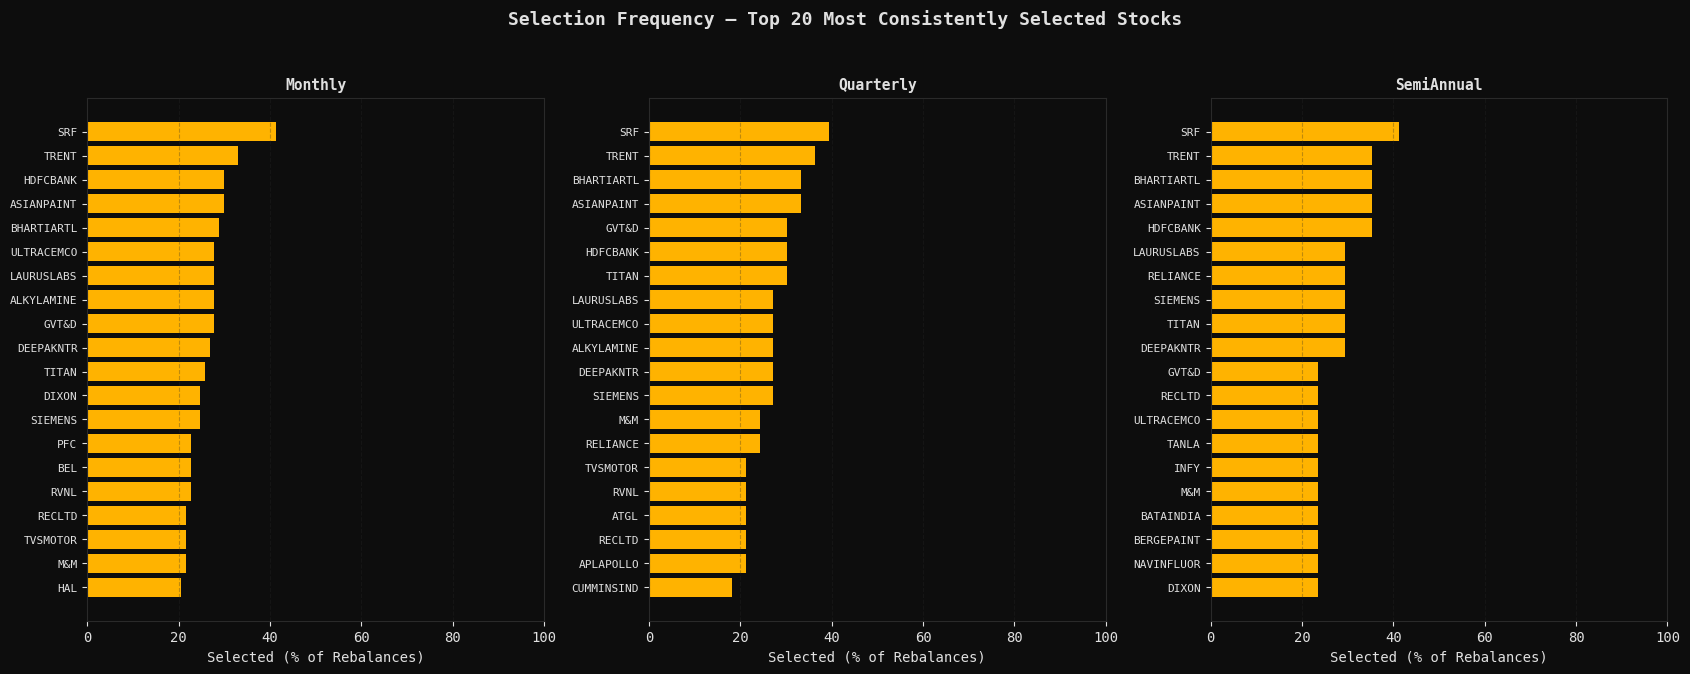

Saved -> .\output\03_research_selection_frequency.png


In [23]:
selection_freq_rows = []
for freq_name, dates in REBAL_DATES_BY_FREQ.items():
    n_rebalances = len(dates)
    counts = {}
    for rd in dates:
        for ticker in SELECTIONS[(freq_name, rd)].index:
            counts[ticker] = counts.get(ticker, 0) + 1
    for ticker, cnt in counts.items():
        selection_freq_rows.append({
            'frequency': freq_name, 'ticker': ticker, 'times_selected': cnt,
            'n_rebalances': n_rebalances, 'selection_pct': 100.0 * cnt / n_rebalances,
        })

selection_frequency_df = pd.DataFrame(selection_freq_rows)

fig, axes = plt.subplots(1, len(REBAL_FREQ_STEP), figsize=(17, 6.5), sharex=True)
for ax, freq_name in zip(axes, REBAL_FREQ_STEP.keys()):
    sub = selection_frequency_df[selection_frequency_df['frequency'] == freq_name].sort_values(
        'selection_pct', ascending=True
    ).tail(TOP_FREQ_CHART_N)
    y_pos = np.arange(len(sub))
    colors_bar = [ACCENT if v >= 50 else COLORS[4] for v in sub['selection_pct']]
    ax.barh(y_pos, sub['selection_pct'], color=colors_bar)
    ax.set_yticks(y_pos)
    ax.set_yticklabels([t.replace('.NS', '') for t in sub['ticker']], fontsize=8)
    ax.set_xlabel('Selected (% of Rebalances)')
    ax.set_title(freq_name, fontsize=10.5, fontweight='bold', color=TEXT_COLOR)
    ax.grid(True, axis='x', alpha=0.3)
    ax.set_xlim(0, 100)

fig.suptitle(f'Selection Frequency — Top {TOP_FREQ_CHART_N} Most Consistently Selected Stocks',
             fontsize=13, fontweight='bold', color=TEXT_COLOR, y=1.03)
plt.tight_layout()
path = os.path.join(OUTPUT_DIR, '03_research_selection_frequency.png')
plt.savefig(path, dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print(f'Saved -> {path}')


### Cell R12 — Research Output 7: Composite Score Ranking Chart (Latest Rebalance)

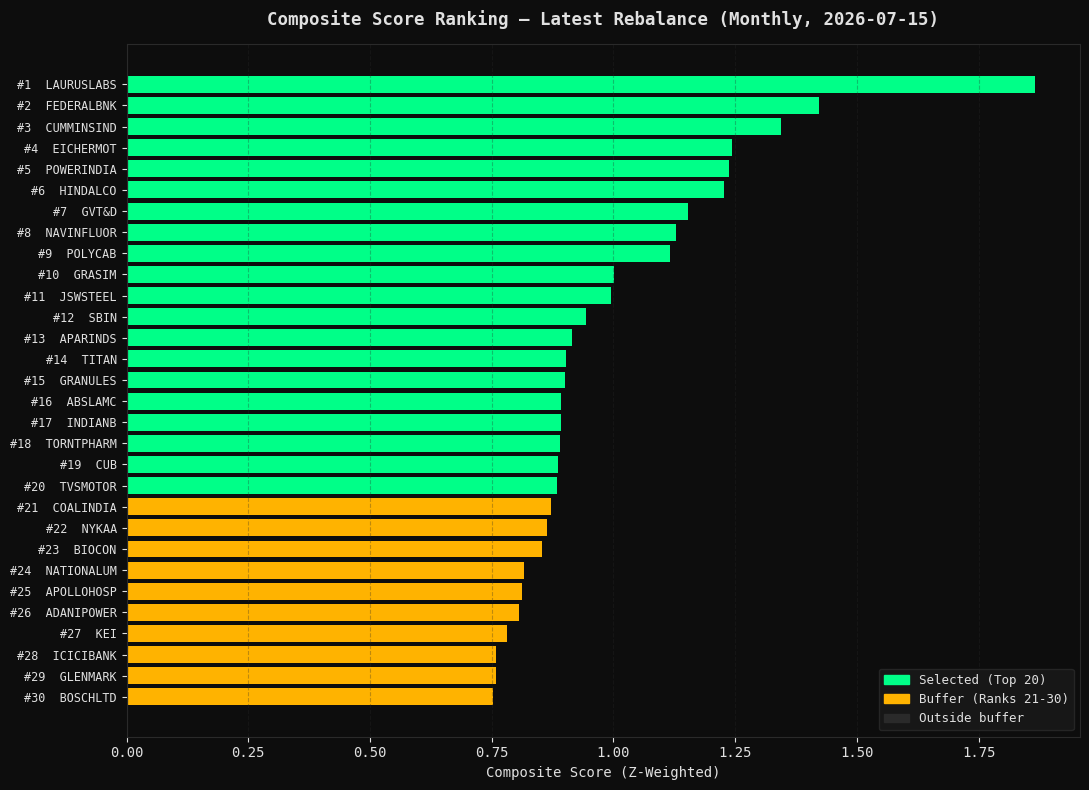

Saved -> .\output\03_research_composite_score_ranking.png


In [24]:
_latest_freq = 'Monthly'
_latest_rd = REBAL_DATES_BY_FREQ[_latest_freq][-1]

chart_sub = ranked_universe_panel[
    (ranked_universe_panel['frequency'] == _latest_freq) &
    (ranked_universe_panel['rebalance_date'] == _latest_rd) &
    (ranked_universe_panel['rank'] <= RANK_CHART_TOP_N)
].sort_values('rank')

bar_colors = []
for _, r in chart_sub.iterrows():
    if r['selected_top20']:
        bar_colors.append(ACCENT)
    elif BUFFER_RANK_START <= r['rank'] <= BUFFER_RANK_END:
        bar_colors.append('#FFB300')
    else:
        bar_colors.append(GRID_COLOR)

fig, ax = plt.subplots(figsize=(11, 8))
y_pos = np.arange(len(chart_sub))
ax.barh(y_pos, chart_sub['composite_score'], color=bar_colors)
ax.set_yticks(y_pos)
ax.set_yticklabels(
    [f"#{int(rank)}  {t.replace('.NS', '')}" for rank, t in zip(chart_sub['rank'], chart_sub['ticker'])],
    fontsize=8.5
)
ax.invert_yaxis()
ax.axvline(0, color=GRID_COLOR, linewidth=0.8)
ax.set_xlabel('Composite Score (Z-Weighted)')
ax.set_title(f'Composite Score Ranking — Latest Rebalance ({_latest_freq}, {_latest_rd.date()})',
             fontsize=12.5, fontweight='bold', color=TEXT_COLOR, pad=14)
ax.grid(True, axis='x', alpha=0.3)

legend_elems = [
    mpatches.Patch(color=ACCENT, label=f'Selected (Top {TARGET_PORTFOLIO_SIZE})'),
    mpatches.Patch(color='#FFB300', label=f'Buffer (Ranks {BUFFER_RANK_START}-{BUFFER_RANK_END})'),
    mpatches.Patch(color=GRID_COLOR, label='Outside buffer'),
]
ax.legend(handles=legend_elems, fontsize=9, loc='lower right')

plt.tight_layout()
path = os.path.join(OUTPUT_DIR, '03_research_composite_score_ranking.png')
plt.savefig(path, dpi=150, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print(f'Saved -> {path}')


### Cell R13 — Save Portfolio Research Diagnostics to data/

In [25]:
turnover_log.to_csv(os.path.join(DATA_DIR, 'portfolio_turnover_log.csv'), index=False)
selection_frequency_df.to_csv(os.path.join(DATA_DIR, 'selection_frequency.csv'), index=False)
sector_allocation_df.to_csv(os.path.join(DATA_DIR, 'sector_allocation.csv'), index=False)
capclass_allocation_df.to_csv(os.path.join(DATA_DIR, 'capclass_allocation.csv'), index=False)

print('Saved to data/:')
for f in ['ranked_universe_panel.csv', 'ticker_sector_map.csv', 'portfolio_turnover_log.csv',
          'selection_frequency.csv', 'sector_allocation.csv', 'capclass_allocation.csv']:
    print(f'  {f}')

print()
print('Portfolio Research section complete -- all outputs above are for interpretation/review only '
      'and were not used anywhere in the construction logic (Cells 1-12).')


Saved to data/:
  ranked_universe_panel.csv
  ticker_sector_map.csv
  portfolio_turnover_log.csv
  selection_frequency.csv
  sector_allocation.csv
  capclass_allocation.csv

Portfolio Research section complete -- all outputs above are for interpretation/review only and were not used anywhere in the construction logic (Cells 1-12).


## Notebook Summary

| Cell | Action | Result |
|---|---|---|
| 1 | Install packages | pandas, numpy, matplotlib, scipy |
| 2 | Configuration & dark theme | Target size 20, 3 frequencies, 2 weighting schemes, ERC params |
| 3 | Load NB01/NB02 outputs | Factor panel, composite score panel, daily returns, study window |
| 4 | Subset monthly grid by frequency | Monthly / Quarterly (every 3rd) / Semi-Annual (every 6th) |
| 5 | Top-20 selection per (frequency, date) | Ranked by composite score; under-target dates logged |
| 6 | Diagnostic: portfolio size over time | Chart, by frequency |
| 7 | Equal Weight scheme | 1/N per selected stock |
| 8 | True ERC optimizer (scipy SLSQP) | 756d trailing covariance, shrinkage + fallback safeguards |
| 9 | Build portfolio holdings panel | Long format, all frequency x scheme combinations |
| 10 | Diagnostic: concentration (HHI / effective N) | ERC vs Equal Weight, by frequency |
| 11 | Diagnostic: ERC robustness / fallback log | Near-singular covariance & insufficient-history events |
| 12 | Save outputs | `portfolio_holdings.csv` + 3 diagnostic CSVs |
| R1 | Dark-themed table renderer (shared helper) | `render_dark_table()` |
| R2 | Sector/Industry metadata (yfinance, cached per ticker) | `ticker_sector_map.csv`; brought forward from NB05 |
| R3 | AMFI Large/Mid classification, as-of each rebalance date | Reuses NB01's membership matrix |
| R4 | Build full ranked-universe panel (research only) | All eligible stocks, not just Top 20 |
| R5 | Save ranked-universe panel | `ranked_universe_panel.csv` |
| R6 | Research Output 1: Top-20 portfolio table | Per frequency, latest rebalance |
| R7 | Research Output 2: Buffer/watchlist (ranks 21-30) | Per frequency, latest rebalance |
| R8 | Research Output 3: Sector allocation | EW vs ERC, per frequency |
| R9 | Research Output 4: Large vs Mid Cap allocation | EW vs ERC, per frequency |
| R10 | Research Output 5: Stocks added/removed per rebalance | Top-20 only, per frequency |
| R11 | Research Output 6: Selection frequency | Per frequency (not comparable across frequencies as raw counts) |
| R12 | Research Output 7: Composite score ranking chart | Latest Monthly rebalance, Top 30 |
| R13 | Save research diagnostics | `portfolio_turnover_log.csv` + 3 more CSVs |

**Key methodological notes carried forward:**
1. **No additional liquidity filter was applied** beyond the factor panel's existing history
   requirement — this was an explicit decision (confirmed with the user), not an oversight. If a
   future notebook revisits this, that decision should be revisited deliberately, not assumed away.
2. **ERC covariance lookback is 756 trading days**, matching the Max Drawdown/Beta window used
   throughout the project, for consistency across the whole factor/risk model.
3. **Under-sized portfolios (< 20 stocks)** are handled by taking all eligible stocks and logging the
   event — no filtering rule is loosened to force exactly 20 names.
4. **ERC robustness safeguards:** covariance matrices are shrunk toward their diagonal when the
   condition number is extreme, and the optimizer falls back to Equal Weight (logged, not silent) when
   there is insufficient trailing history or the optimizer fails to converge. Both are diagnostic, not
   silent — see `erc_diagnostics_log.csv`.
5. **This notebook produces weights only.** No returns are compounded, no performance metrics exist
   yet, and no transaction costs are applied — all of that is explicitly deferred to NB04/NB05, per
   the confirmed scope boundary at the top of this notebook.
6. **No starting capital, no "portfolio value" language** appears anywhere in this notebook, per the
   standing project-wide rule.
7. **The Portfolio Research section is read-only with respect to construction.** It is built entirely
   from what Cells 1-12 already produced and saved; nothing in it feeds back into stock selection,
   weighting, or the Top-20 cutoff. It exists purely for PM-facing interpretation.
8. **Sector/Industry fetching was brought forward from NB05 into this notebook** (confirmed with the
   user), cached once per ticker to `ticker_sector_map.csv` so NB05 does not need to re-fetch it.
   Missing values are explicitly labelled `'Unknown'`, never silently dropped — yfinance's
   sector/industry coverage is known to be patchy for some NSE mid-caps, a disclosed limitation.
9. **Selection frequency is reported separately per rebalancing frequency**, not pooled, since
   Monthly/Quarterly/Semi-Annual have different numbers of rebalance dates and a raw count would not
   be comparable across them.
10. **Added/removed stocks track the Top-20 selection only** (confirmed with the user), i.e. what
    actually changed in the portfolio a PM would be holding — not the full ranked universe's entries
    and exits from eligibility.
